## 1. Zmiany zachowań płatniczych w czasie

In [193]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/dataset_clean.csv")

print("Liczba rekordów:", len(df))
print("Liczba kolumn:", df.shape[1])

display(df.head())

date_columns = [
    "document_create_date",
    "due_in_date",
    "clear_date"
]

for col in date_columns:
    df[col] = pd.to_datetime(
        df[col],
        dayfirst=True,
        errors="coerce"
    )

df[date_columns].dtypes

Liczba rekordów: 48839
Liczba kolumn: 16


,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,document_create_date,due_in_date,invoice_currency,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen,days_late,paid_late
0,U001,200769623,WAL-MAR corp,2020-02-11,2020,1930438491,2020-01-25,2020-02-10,USD,54273.28,2020-01-26,NAH4,1.930438e+09,0,1.0,1.0
1,U001,200980828,BEN E,2019-08-08,2019,1929646410,2019-07-22,2019-08-11,USD,79656.60,2019-07-22,NAD1,1.929646e+09,0,0.0,0.0
2,U001,200792734,MDV/ trust,2019-12-30,2019,1929873765,2019-09-14,2019-09-29,USD,2253.86,2019-09-14,NAA8,1.929874e+09,0,92.0,1.0
3,CA02,140105686,SYSC llc,NaN,2020,2960623488,2020-03-30,2020-04-10,CAD,3299.70,2020-03-31,CA10,2.960623e+09,1,NaN,NaN
4,U001,200769623,WAL-MAR foundation,2019-11-25,2019,1930147974,2019-11-13,2019-11-28,USD,33133.29,2019-11-13,NAH4,1.930148e+09,0,0.0,0.0


/var/folders/xd/zfsynllx73dfy82g1byyz0wr0000gn/T/ipykernel_21307/565153241.py:19: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col] = pd.to_datetime(


document_create_date    datetime64[ns]
due_in_date             datetime64[ns]
clear_date              datetime64[ns]
dtype: object

In [194]:
closed = df[
    (df["isOpen"] == 0) &
    (df["paid_late"].notna())
].copy()

print("Liczba wszystkich faktur:", len(df))
print("Liczba zamkniętych faktur:", len(closed))

print(
    "Początek danych:",
    closed["document_create_date"].min()
)

print(
    "Koniec danych:",
    closed["document_create_date"].max()
)

Liczba wszystkich faktur: 48839
Liczba zamkniętych faktur: 39158
Początek danych: 2018-12-26 00:00:00
Koniec danych: 2020-03-02 00:00:00


In [195]:
closed["year_month"] = (
    closed["document_create_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly = (
    closed.groupby("year_month")
    .agg(
        liczba_faktur=("paid_late", "size"),
        procent_opoznionych=("paid_late", "mean"),
        srednie_opoznienie=("days_late", "mean"),
        mediana_opoznienia=("days_late", "median"),
        mediana_kwoty=("total_open_amount", "median")
    )
)

monthly["procent_opoznionych"] *= 100

min_invoices = 100

monthly = monthly[
    monthly["liczba_faktur"] >= min_invoices
].copy()

display(monthly.round(2))

,liczba_faktur,procent_opoznionych,srednie_opoznienie,mediana_opoznienia,mediana_kwoty
year_month,,,,,
2018-12,190,35.26,3.83,0.0,13543.66
2019-01,2653,44.59,3.30,0.0,18130.16
2019-02,2698,44.77,3.22,0.0,16297.80
2019-03,3196,41.30,3.12,0.0,16224.02
2019-04,3113,41.86,3.16,0.0,16745.48
2019-05,2961,41.74,2.48,0.0,16741.64
2019-06,2970,43.10,2.85,0.0,17547.38
2019-07,2945,42.72,2.86,0.0,16106.56
2019-08,3051,42.90,2.67,0.0,18353.82


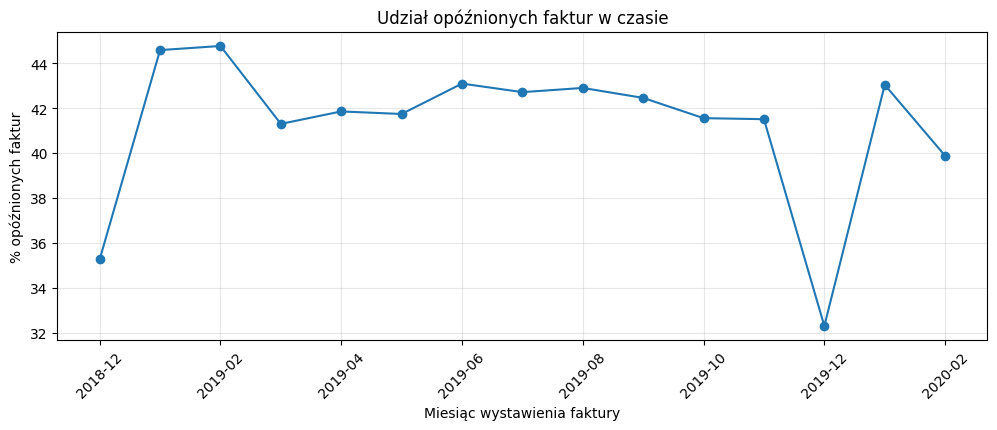

In [196]:
monthly["procent_opoznionych"].plot(
    figsize=(12, 4),
    marker="o"
)

plt.title("Udział opóźnionych faktur w czasie")
plt.xlabel("Miesiąc wystawienia faktury")
plt.ylabel("% opóźnionych faktur")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

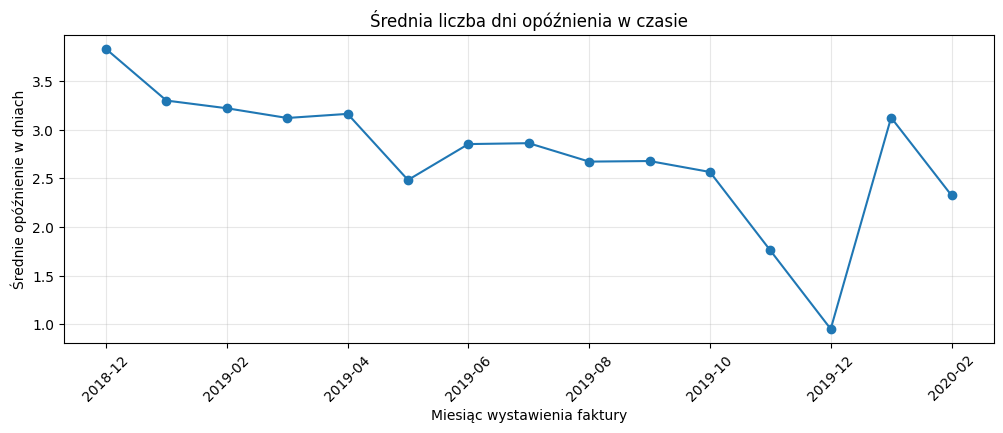

In [197]:
monthly["srednie_opoznienie"].plot(
    figsize=(12, 4),
    marker="o"
)

plt.title("Średnia liczba dni opóźnienia w czasie")
plt.xlabel("Miesiąc wystawienia faktury")
plt.ylabel("Średnie opóźnienie w dniach")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

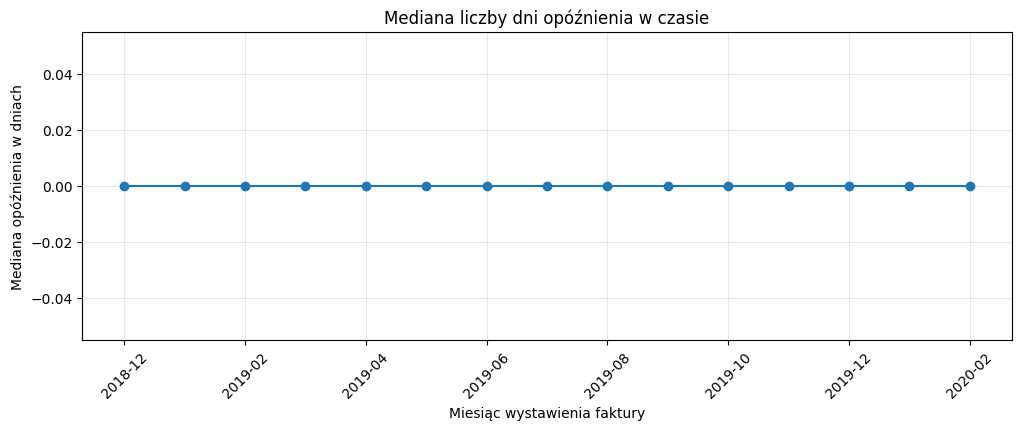

In [198]:
monthly["mediana_opoznienia"].plot(
    figsize=(12, 4),
    marker="o"
)

plt.title("Mediana liczby dni opóźnienia w czasie")
plt.xlabel("Miesiąc wystawienia faktury")
plt.ylabel("Mediana opóźnienia w dniach")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

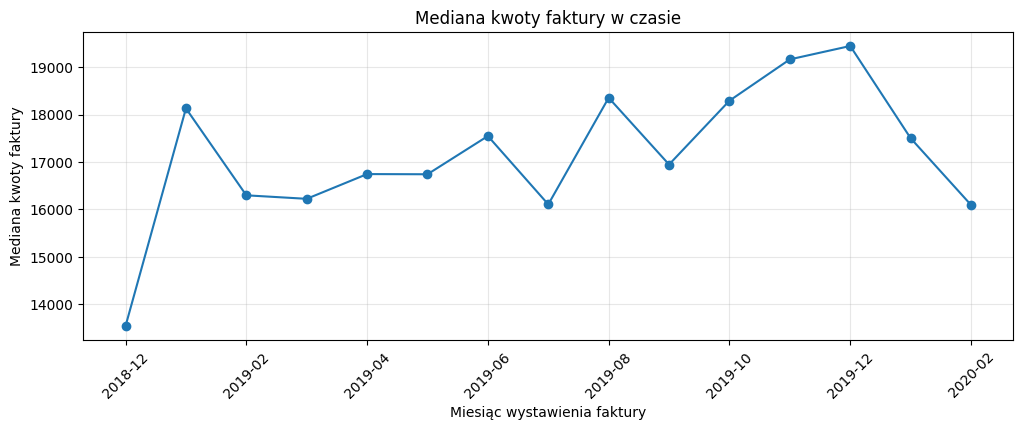

In [199]:
monthly["mediana_kwoty"].plot(
    figsize=(12, 4),
    marker="o"
)

plt.title("Mediana kwoty faktury w czasie")
plt.xlabel("Miesiąc wystawienia faktury")
plt.ylabel("Mediana kwoty faktury")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

Udział opóźnionych faktur przez większość okresu utrzymywał się na podobnym poziomie, około 41–45%. Wyjątkiem był grudzień 2019 roku, kiedy udział ten wyraźnie spadł.

Średnia liczba dni opóźnienia stopniowo malała w 2019 roku, a na początku 2020 roku ponownie wzrosła. Może to wskazywać na zmianę zachowań płatniczych w czasie.

Mediana opóźnienia wynosiła 0 dni, więc co najmniej połowa faktur była płacona w terminie. Dodatnia średnia oznacza jednak, że część faktur miała większe opóźnienia.

Mediana kwoty faktury zmieniała się między miesiącami, ale nie widać wyraźnego stałego trendu. Wyniki sugerują pewne zmiany w czasie, ale nie potwierdzają jeszcze statystycznie występowania concept drift.

## 2. Korelacje cech ze zmienną docelową

In [200]:
closed["payment_term_days"] = (
    closed["due_in_date"] -
    closed["document_create_date"]
).dt.days

numeric_columns = [
    "total_open_amount",
    "payment_term_days",
    "buisness_year",
    "paid_late"
]

numeric_columns = [
    col for col in numeric_columns
    if col in closed.columns
]

In [201]:
spearman_corr = (
    closed[numeric_columns]
    .corr(method="spearman")
)

display(spearman_corr.round(3))

,total_open_amount,payment_term_days,buisness_year,paid_late
total_open_amount,1.000,-0.069,-0.006,0.047
payment_term_days,-0.069,1.000,0.340,-0.035
buisness_year,-0.006,0.340,1.000,-0.005
paid_late,0.047,-0.035,-0.005,1.000


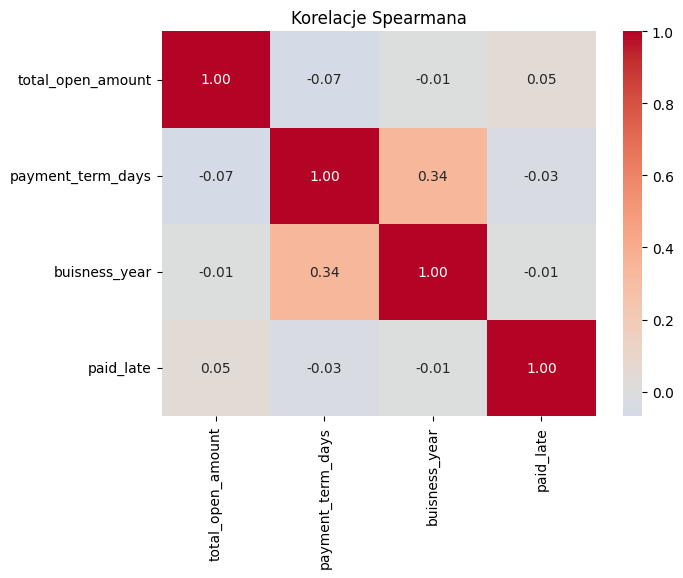

In [202]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    spearman_corr,
    annot=True,
    center=0,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Korelacje Spearmana")
plt.show()

In [203]:
target_correlations = (
    spearman_corr["paid_late"]
    .drop("paid_late")
    .sort_values(
        key=abs,
        ascending=False
    )
)

display(
    target_correlations
    .to_frame("korelacja_z_paid_late")
    .round(3)
)

,korelacja_z_paid_late
total_open_amount,0.047
payment_term_days,-0.035
buisness_year,-0.005


Wszystkie korelacje ze zmienną `paid_late` są bardzo słabe i bliskie 0.

Najwyższą korelację ma `total_open_amount`, ale jej wartość wynosi tylko około 0,05, więc zależność jest praktycznie pomijalna.

`payment_term_days` ma bardzo słabą korelację ujemną, a `buisness_year` prawie nie jest związany z opóźnieniem płatności.

Oznacza to, że pojedyncze cechy numeryczne nie wyjaśniają dobrze, czy faktura zostanie zapłacona po terminie. Zależności mogą być bardziej złożone i nieliniowe.

Najsilniejsza zależność między samymi cechami występuje między
`payment_term_days` i `buisness_year`, ale nie dotyczy bezpośrednio
zmiennej docelowej.

## 3. Sezonowość płatności

In [204]:
closed["invoice_month"] = (
    closed["document_create_date"].dt.month
)

month_summary = (
    closed.groupby("invoice_month")
    .agg(
        liczba_faktur=("paid_late", "size"),
        procent_opoznionych=("paid_late", "mean"),
        srednie_opoznienie=("days_late", "mean"),
        mediana_opoznienia=("days_late", "median")
    )
)

month_summary["procent_opoznionych"] *= 100

display(month_summary.round(2))

,liczba_faktur,procent_opoznionych,srednie_opoznienie,mediana_opoznienia
invoice_month,,,,
1,5262,43.82,3.21,0.0
2,5025,42.51,2.81,0.0
3,3197,41.32,3.14,0.0
4,3113,41.86,3.16,0.0
5,2961,41.74,2.48,0.0
6,2970,43.10,2.85,0.0
7,2945,42.72,2.86,0.0
8,3051,42.90,2.67,0.0
9,2911,42.46,2.68,0.0


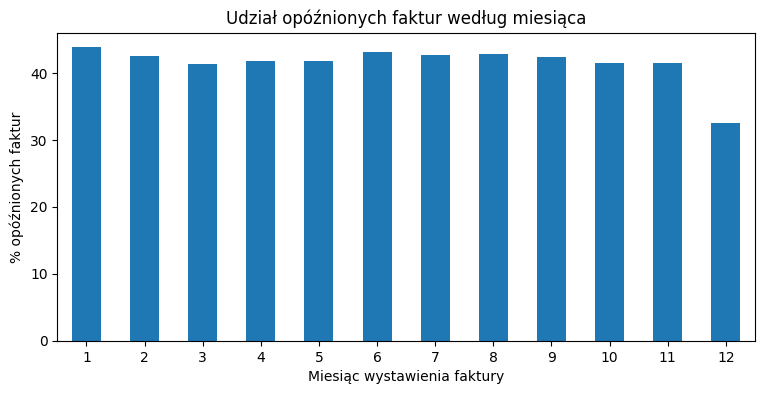

In [205]:
month_summary["procent_opoznionych"].plot(
    kind="bar",
    figsize=(9, 4)
)

plt.title("Udział opóźnionych faktur według miesiąca")
plt.xlabel("Miesiąc wystawienia faktury")
plt.ylabel("% opóźnionych faktur")
plt.xticks(rotation=0)
plt.show()

In [206]:
closed["invoice_dayofweek"] = (
    closed["document_create_date"].dt.dayofweek
)

weekday_summary = (
    closed.groupby("invoice_dayofweek")
    .agg(
        liczba_faktur=("paid_late", "size"),
        procent_opoznionych=("paid_late", "mean"),
        srednie_opoznienie=("days_late", "mean")
    )
)

weekday_summary["procent_opoznionych"] *= 100

In [207]:
weekday_names = {
    0: "Poniedziałek",
    1: "Wtorek",
    2: "Środa",
    3: "Czwartek",
    4: "Piątek",
    5: "Sobota",
    6: "Niedziela"
}

weekday_summary.index = (
    weekday_summary.index.map(weekday_names)
)

display(weekday_summary.round(2))

,liczba_faktur,procent_opoznionych,srednie_opoznienie
invoice_dayofweek,,,
Poniedziałek,5978,40.77,3.14
Wtorek,7162,37.52,2.62
Środa,6873,40.03,2.68
Czwartek,6365,45.81,3.09
Piątek,5776,49.43,3.01
Sobota,4558,43.22,1.89
Niedziela,2446,32.79,1.84


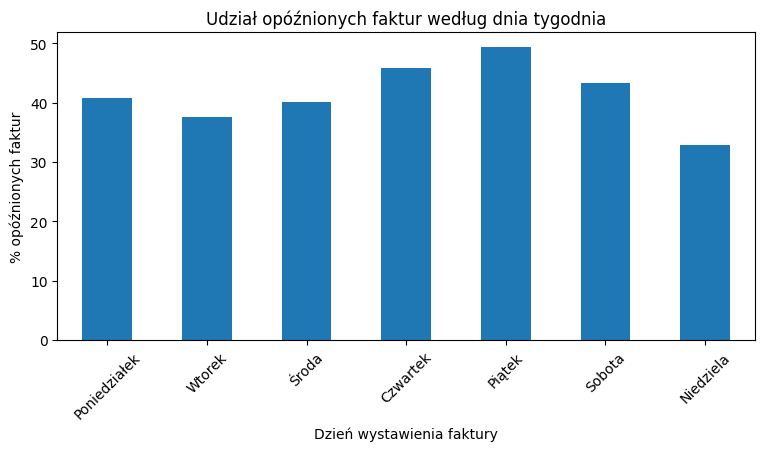

In [208]:
weekday_summary["procent_opoznionych"].plot(
    kind="bar",
    figsize=(9, 4)
)

plt.title("Udział opóźnionych faktur według dnia tygodnia")
plt.xlabel("Dzień wystawienia faktury")
plt.ylabel("% opóźnionych faktur")
plt.xticks(rotation=45)
plt.show()

Udział opóźnionych faktur w większości miesięcy był podobny i wynosił około 41–44%. Wyraźnie niższy wynik pojawił się w grudniu, gdzie udział opóźnień spadł do około 33%.

Większe różnice widać między dniami tygodnia. Najwyższy udział opóźnionych faktur wystąpił dla faktur wystawionych w piątek, a najniższy dla faktur wystawionych w niedzielę.

Może to sugerować, że dzień tygodnia wystawienia faktury jest bardziej użyteczną cechą niż sam miesiąc. Wyniki trzeba jednak interpretować ostrożnie, ponieważ dane obejmują ograniczony okres.